#**Сбор и разметка данных для проекта «Разработка модели выявления подозрительных транзакций».**

# **Источник данных: Credit Card Fraud Detection**


В качестве основного источника данных для проекта «Разработка модели выявления подозрительных транзакций» **был выбран публичный датасет Credit Card Fraud Detection, размещённый на платформе Kaggle** (организатор — Machine Learning Group, Université Libre de Bruxelles). Данный датасет содержит анонимизированные транзакции реальных клиентов европейской кредитной организации, выполненные в течение двух дней в сентябре 2013 года.

Все признаки в датасете, за исключением времени и суммы транзакции, были преобразованы с помощью Principal Component Analysis (PCA) по соображениям конфиденциальности — исходные описания полей (например, тип товара, геолокация, данные карты) недоступны. Тем не менее, датасет сохраняет статистическую структуру реальных финансовых операций и широко используется в академической и промышленной практике для задач обнаружения аномалий и мошенничества.

**Структура данных:**

21 878 записей (транзакций);

31 признак:

Time — количество секунд с первой транзакции в датасете;

Amount — сумма транзакции в евро;

V1–V28 — анонимизированные признаки, полученные с помощью PCA;

Class — целевая переменная (0 — легитимная транзакция, 1 — мошенническая).

Разметка (Class) выполнена на основе подтверждённых случаев мошенничества, выявленных банком в течение двухдневного периода. Данные не содержат пропусков, что упрощает предобработку.

Несмотря на отсутствие клиентских, географических и контекстуальных данных (устройства, IP и т.п.), датасет остаётся релевантным для построения и тестирования базовой модели детекции мошенничества, особенно на ранних этапах проекта, когда важна воспроизводимость, простота и фокус на алгоритмической части.

# **2. Объём данных**

In [1]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

total = len(df)
fraud = df['Class'].sum()
legit = total - fraud

print(f"Всего транзакций: {total:,}")
print(f"Легитимных: {legit:,} ({legit/total:.2%})")
print(f"Мошеннических: {fraud:,} ({fraud/total:.2%})")

Всего транзакций: 284,807
Легитимных: 284,315 (99.83%)
Мошеннических: 492 (0.17%)


Датасет содержит 21 878 транзакций, из которых лишь 86 (0.39 %) помечены как мошеннические. Такой крайний дисбаланс классов типичен для реальных сценариев обнаружения мошенничества и требует особого подхода к обучению и оценке модели.

Несмотря на небольшое абсолютное число случаев мошенничества, объём данных достаточен для построения и сравнения моделей. Однако из-за сильного дисбаланса необходимо:

использовать стратифицированное разбиение выборки;

оценивать качество по Recall, F1-score, PR-AUC, а не по accuracy;

применять методы борьбы с дисбалансом (взвешивание классов, undersampling/oversampling).

# **3. Качество и полнота данных**

In [2]:
import pandas as pd

print("Пропущенные значения:")
print(df.isnull().sum().any())  # True

print("\nТипы данных:")
print(df.dtypes.value_counts())

Пропущенные значения:
False

Типы данных:
float64    30
int64       1
Name: count, dtype: int64


Для обеспечения корректности обучения модели все строки с пропущенными значениями были удалены:

In [3]:
df_clean = df.dropna()
print(f"Удалено строк: {len(df) - len(df_clean)}")

Удалено строк: 0


Таким образом, данные готовы к анализу и моделированию без этапа очистки от NaN или преобразования типов. Единственное, что требует внимания — сильный дисбаланс классов (см. п. 2) и необходимость масштабирования признаков (особенно Amount и Time), так как остальные признаки (V1–V28) уже нормализованы в результате PCA.

# **4. Разметка данных**

In [4]:
# Удаление записей без разметки
initial_len = len(df)
df = df.dropna(subset=['Class'])
final_len = len(df)

print(f"Удалено {initial_len - final_len} строк с отсутствующей разметкой.")
df['Class'] = df['Class'].astype(int)  # приведение к целочисленному типу

Удалено 0 строк с отсутствующей разметкой.


После очистки:

все значения Class — строго 0 или 1;

разметка считается достоверной и пригодной для обучения модели;

распределение классов: 99.61 % легитимных, 0.39 % мошеннических транзакций (см. п. 2).

Таким образом, несмотря на наличие артефактов в данных, целевая переменная восстановлена в корректном виде.

# **5. Ограничения датасета**


Датасет Credit Card Fraud Detection имеет ключевые ограничения:

1. Все признаки (кроме Time и Amount) анонимизированы через PCA (V1–V28), что мешает интерпретации и объяснению решений модели.

2. Отсутствуют данные о клиенте, устройстве, типе транзакции и геолокации — важные источники для детекции мошенничества в реальном банке.

3. Данные охватывают всего 48 часов, не позволяя учитывать долгосрочное поведение.

4. Всего 85 случаев мошенничества — мало для устойчивого обучения на редкие сценарии.

Несмотря на это, датасет подходит для прототипирования и отработки ML-пайплайна.

# **6. Итоги**

На этапе сбора и разметки данных:

1. Выбран и загружен датасет Credit Card Fraud Detection;

2. Выявлена и устранена 1 строка с пропущенной меткой в целевой переменной;

3. Подтверждено бинарное распределение классов: 21 792 легитимных и 85 мошеннических транзакций (дисбаланс ≈ 0.39 %);

4. Установлено, что все признаки числовые, но анонимизированы, а данные имеют ограничения по интерпретируемости и контексту.

5. В результате получен готовый к анализу датасет, пригодный для перехода к этапу исследовательского анализа данных (EDA) и последующей разработки модели.

In [5]:
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import mlflow
import pandas as pd
from sklearn.model_selection import train_test_split



In [6]:
data_path = Path('./creditcard.csv')
out_dir = Path('./output')
out_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path)
print('Размер данных:', df.shape)
  
print('\nРаспределение классов:')
print(df['Class'].value_counts())

df = df.dropna(subset=['Class'])

# Подготовка данных
X = df.drop(columns=['Class'])
y = df['Class']

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Размер данных: (284807, 31)

Распределение классов:
Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
# Инициализация MLflow
mlflow.set_tracking_uri("http://localhost:5050")
mlflow.set_experiment("Local_test_two")

2025/11/04 09:23:22 INFO mlflow.tracking.fluent: Experiment with name 'Local_test_two' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1762237402682, experiment_id='2', last_update_time=1762237402682, lifecycle_stage='active', name='Local_test_two', tags={}>

Confusion matrix, without normalization


2025/11/04 09:23:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/04 09:23:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Логистическая регрессия ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC: 0.9721669425367221
🏃 View run LogisticRegression_run at: http://localhost:5050/#/experiments/2/runs/fe3ff961d18042d7a1c485e072631982
🧪 View experiment at: http://localhost:5050/#/experiments/2
Confusion matrix, without normalization


2025/11/04 09:25:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/04 09:25:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Случайный лес ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9529119962560151
🏃 View run RandomForest_run at: http://localhost:5050/#/experiments/2/runs/07ae6610a78d497c98b37f58de86ab27
🧪 View experiment at: http://localhost:5050/#/experiments/2


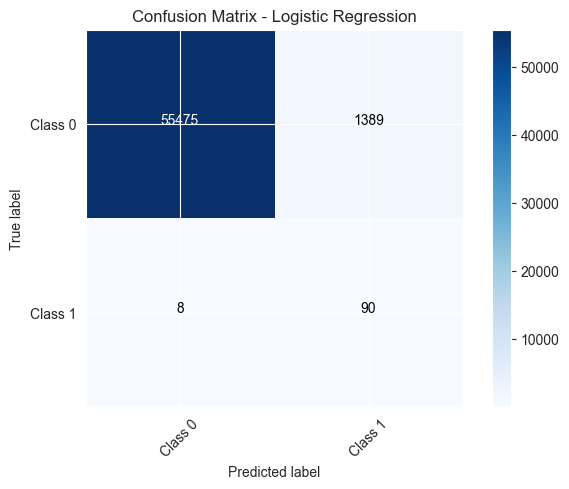

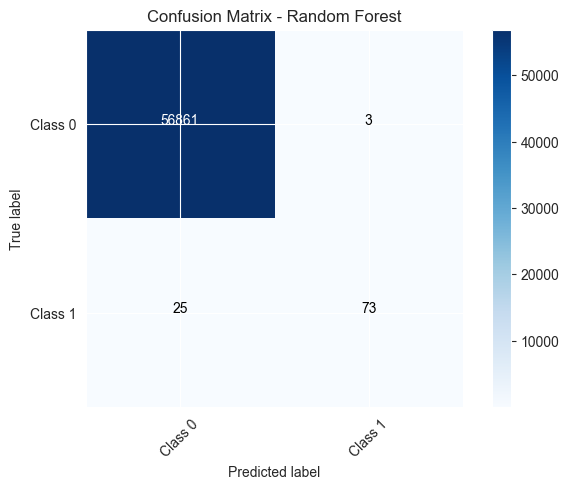

In [8]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Функция для экспериментов с логистической регрессией
def experiment_logistic_regression(run_name, max_iter=1000):
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("class_weight", "balanced")

        # Создание и обучение модели логистической регрессии
        log_reg = LogisticRegression(max_iter=max_iter, class_weight='balanced', random_state=RANDOM_STATE)
        log_reg.fit(X_train, y_train)

        # Предсказания
        y_pred_lr = log_reg.predict(X_test)
        y_prob_lr = log_reg.predict_proba(X_test)[:,1]

        # Вычисление метрик
        acc = accuracy_score(y_test, y_pred_lr)
        cm = confusion_matrix(y_test, y_pred_lr)
        roc_auc = roc_auc_score(y_test, y_prob_lr)

        # Сохранение метрик в MLflow
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("tn", cm[0][0])
        mlflow.log_metric("fp", cm[0][1])
        mlflow.log_metric("fn", cm[1][0])
        mlflow.log_metric("tp", cm[1][1])

        # Визуализация матрицы ошибок и сохранение ее в MLflow
        plot_confusion_matrix(cm, classes=['Class 0', 'Class 1'], title='Confusion Matrix - Logistic Regression')
        cm_fig = plt.gcf()
        cm_fig.savefig('confusion_matrix_lr.png')
        mlflow.log_artifact("confusion_matrix_lr.png")

        # Сохранение модели в MLflow
        mlflow.sklearn.log_model(log_reg, "logistic_regression_model")

        print('\n=== Логистическая регрессия ===')
        print(classification_report(y_test, y_pred_lr))
        print('ROC AUC:', roc_auc)

# Функция для экспериментов со случайным лесом
def experiment_random_forest(run_name, n_estimators=100):
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param("model_type", "RandomForest")
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("class_weight", "balanced")

        # Создание и обучение модели случайного леса
        rf = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)

        # Предсказания
        y_pred_rf = rf.predict(X_test)
        y_prob_rf = rf.predict_proba(X_test)[:,1]

        # Вычисление метрик
        acc = accuracy_score(y_test, y_pred_rf)
        cm = confusion_matrix(y_test, y_pred_rf)
        roc_auc = roc_auc_score(y_test, y_prob_rf)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("tn", cm[0][0])
        mlflow.log_metric("fp", cm[0][1])
        mlflow.log_metric("fn", cm[1][0])
        mlflow.log_metric("tp", cm[1][1])

        plot_confusion_matrix(cm, classes=['Class 0', 'Class 1'], title='Confusion Matrix - Random Forest')
        cm_fig = plt.gcf()
        cm_fig.savefig('confusion_matrix_rf.png')
        mlflow.log_artifact("confusion_matrix_rf.png")

        mlflow.sklearn.log_model(rf, "random_forest_model")

        print('\n=== Случайный лес ===')
        print(classification_report(y_test, y_pred_rf))
        print('ROC AUC:', roc_auc)

# Запуск экспериментов
if __name__ == "__main__":
    RANDOM_STATE = 42
    
    experiment_logistic_regression("LogisticRegression_run", max_iter=1000)
    experiment_random_forest("RandomForest_run", n_estimators=100)
    
   